# 4. 実施内容（個人ワーク）— サンプル時系列（CSV）の解析

原系列 $y_n$ と 1 次階差系列 $\Delta y_n = y_n - y_{n-1}$ について、教材 `example02_01`〜`example02_04` と同様の手順で以下を実施する。

- **(a)** $y_n$ と $\Delta y_n$ のグラフ
- **(b)** $\Delta y_n$ の ADF 検定（$p \le 0.05$ の確認）と、AIC 最小による AR 次数 $p$ の決定・推定
- **(c)** AR モデルの残差とその PARCOR
- **(d)** 同 AR モデルに基づくカルマンフィルタと長期予測

データ: GitHub `data/Practice02_01_2026+1.csv`（CSV を取得）

## 準備（`example02_01.ipynb` 冒頭と同一）

In [28]:
!pip install japanize-matplotlib
%matplotlib inline

import warnings
warnings.simplefilter('ignore')  # 警告を無視（コメントアウト推奨）

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib  # 日本語化 matplotlib
sns.set(font="IPAexGothic")  # 日本語フォント設定

## 追加パッケージ・データ取得

時系列解析（`statsmodels`）とカルマンフィルタ（`pykalman`）用。CSV を GitHub から保存する。

In [29]:
!pip install -q statsmodels pykalman

import os
import urllib.request

CSV_URL = "https://github.com/takenoko888/sorcecode_4/blob/master/data/Practice02_01_2026%2B1.csv"
CSV_URL_RAW = "https://raw.githubusercontent.com/takenoko888/sorcecode_4/master/data/Practice02_01_2026%2B1.csv"
CSV_PATH = "Practice02_01_2026%2B1.csv"

def _ensure_csv(path, url):
    need_download = True
    if os.path.isfile(path):
        with open(path, "r", encoding="utf-8") as f:
            head = f.readline().strip().lower()
        if "," in head and "html" not in head:
            need_download = False
    if need_download:
        urllib.request.urlretrieve(url, path)
        print("ダウンロード完了:", path)
    else:
        print("既存ファイルを使用:", path)

_ensure_csv(CSV_PATH, CSV_URL_RAW)

既存ファイルを使用: Practice02_01_2026%2B1.csv


## 系列の作成

CSV の `t`, `y` を読み込み、原系列 $y_n$ と 1 次階差系列 $\Delta y_n$ を作成する。

In [30]:
df = pd.read_csv(CSV_PATH)
df["t"] = pd.to_datetime(df["t"])
df = df.sort_values("t").reset_index(drop=True)

t = df["t"].to_numpy()
y = df["y"].astype(float).to_numpy()
dy = np.diff(y)

print(f"データ件数: {len(y)}, Δy 件数: {len(dy)}")
print(f"期間: {df['t'].iloc[0]} 〜 {df['t'].iloc[-1]}")

データ件数: 311, Δy 件数: 310
期間: 2025-07-20 00:00:00+09:00 〜 2025-08-01 22:00:00+09:00


## (a) 原系列 $y_n$ と階差系列 $\Delta y_n$ のプロット

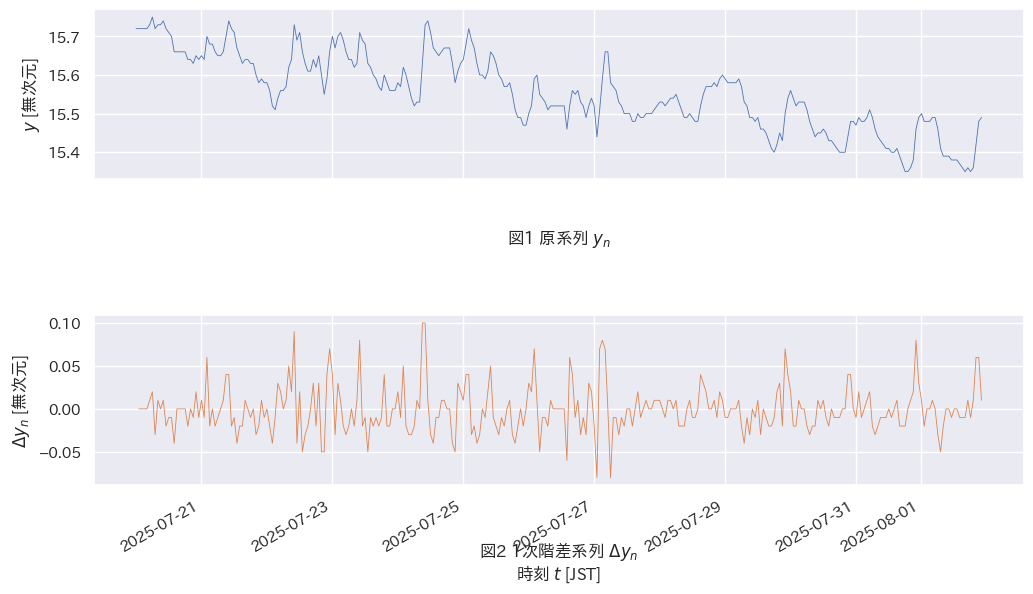

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(t, y, lw=0.6)
axes[0].set_xlabel("時刻 $t$ [JST]", labelpad=6)
axes[0].set_ylabel("$y$ [無次元]")

axes[1].plot(t[1:], dy, lw=0.6, color="C1")
axes[1].set_xlabel("時刻 $t$ [JST]", labelpad=6)
axes[1].set_ylabel("$\\Delta y_n$ [無次元]")

fig.autofmt_xdate(rotation=30, ha="right")
fig.tight_layout()
fig.subplots_adjust(hspace=0.55, bottom=0.25)

for ax, caption, dy in (
    (axes[0], "図1 原系列 $y_n$", 0.04),
    (axes[1], "図2 1次階差系列 $\\Delta y_n$", 0.08),
):
    bbox = ax.get_position()
    fig.text(0.5, bbox.y0 - dy, caption, ha="center", va="top")

plt.show()

## (b) $\Delta y_n$ の ADF 検定と AR($p$)（AIC による次数選択）

訓練区間の階差系列に ADF を実施し、続けて `ar_model.ar_select_order`（`ic='aic'`）で次数を選ぶ。カルマン用の同伴形（`example02_04.ipynb`）は **連続ラグ 1,…,p** を前提とするため、選択結果が部分集合のときは $p=\max(\text{lags})$ の連続 AR に再推定する。

- 使用した手法: ADF 検定、AR($p$) モデル（AIC 最小化）、カルマンフィルタ（状態空間表現）
- モデルの種類: 定数項付き AR($p$)
- モデルパラメータ: $a_0, a_1, \ldots, a_p$ と $\sigma^2$（下の出力で一覧を表示）

In [32]:
import statsmodels.api as sm
from statsmodels.tsa import ar_model, stattools

testdataratio = 0.2
ntest = int(np.ceil(testdataratio * len(dy)))
ntrain = len(dy) - ntest
dy_train = dy[:ntrain]
dy_test = dy[ntrain:]

print(f"訓練 : テスト = {ntrain} : {ntest}")

adf_res = stattools.adfuller(dy_train)
adf_stat, adf_p, adf_usedlag, adf_nobs, adf_crit, adf_icbest = adf_res
print("ADF 検定（訓練区間の Δy）")
print(f"  統計量: {adf_stat:.6g}, p 値: {adf_p:.6g}")
print(f"  使用ラグ数: {adf_usedlag}, 観測数: {adf_nobs}")
if adf_p <= 0.05:
    print("  → p 値が 0.05 以下であり、単位根仮説は有意水準 0.05 で棄却できる（定常性の目安）。")
else:
    print("  → 注意: p 値が 0.05 を超えています。系列や区間の見直しを検討してください。")

maxlag = min(50, max(5, ntrain // 10))
sel = ar_model.ar_select_order(dy_train, maxlag=maxlag, ic="aic")
ords_sel = sel.ar_lags
popt = int(max(ords_sel))
if tuple(ords_sel) != tuple(range(1, popt + 1)):
    print("AIC 選択ラグ:", ords_sel, "→ 同伴形用に連続 AR(1..p) に再推定")
    results = ar_model.AutoReg(dy_train, lags=popt, trend="c").fit()
    ords = tuple(range(1, popt + 1))
else:
    results = ar_model.AutoReg(dy_train, lags=ords_sel, trend="c").fit()
    ords = ords_sel

print(f"AR 次数 p = {popt}, AIC = {results.aic:.4f}")
print(results.summary())

param_names = ["a0"] + [f"a{k}" for k in range(1, popt + 1)]
params = pd.Series(results.params, index=param_names)
print("AR(p) パラメータ（定数項 + 係数）")
print(params.to_string())
print(f"推定分散 sigma^2 = {results.sigma2:.6g}")

訓練 : テスト = 248 : 62
ADF 検定（訓練区間の Δy）
  統計量: -8.58079, p 値: 7.73874e-14
  使用ラグ数: 5, 観測数: 242
  → p 値が 0.05 以下であり、単位根仮説は有意水準 0.05 で棄却できる（定常性の目安）。
AR 次数 p = 24, AIC = -969.4122
                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                  248
Model:                    AutoReg(24)   Log Likelihood                 510.706
Method:               Conditional MLE   S.D. of innovations              0.025
Date:                Tue, 19 May 2026   AIC                           -969.412
Time:                        06:09:33   BIC                           -880.709
Sample:                            24   HQIC                          -933.607
                                  248                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0021      0.002    

## (c) AR モデルの残差とその PARCOR

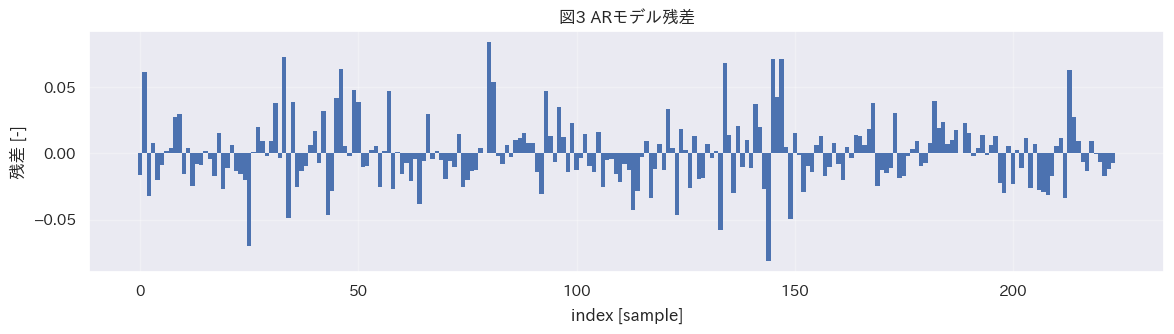

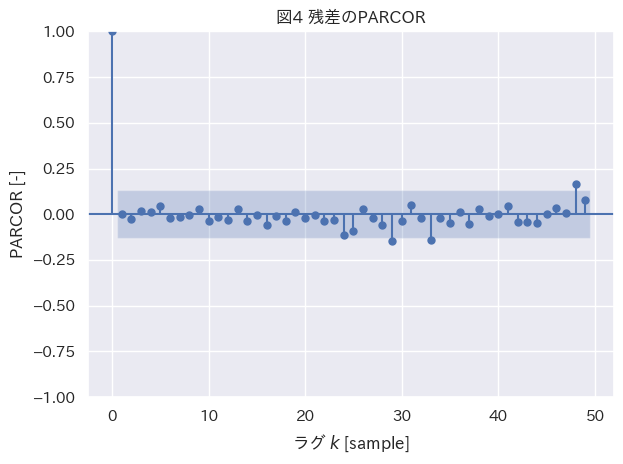

In [ ]:
residual = results.resid
maxlag_plot = min(100, max(10, ntrain // 5))

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.bar(np.arange(len(residual)), residual, width=1.0, edgecolor="none")
ax.set_xlabel("index [sample]", labelpad=6)
ax.set_ylabel("残差 [-]")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.subplots_adjust(bottom=0.22)
fig.text(0.5, 0.02, "図3 ARモデル残差", ha="center", va="bottom")
plt.show()

resid_clean = pd.Series(residual).dropna()
fig = sm.graphics.tsa.plot_pacf(resid_clean, lags=maxlag_plot)
fig.axes[0].set_xlabel("ラグ $k$ [sample]", labelpad=6)
fig.axes[0].set_ylabel("PARCOR [-]")
fig.tight_layout()
fig.subplots_adjust(bottom=0.22)
fig.text(0.5, 0.02, "図4 残差のPARCOR", ha="center", va="bottom")
plt.show()

## (d) カルマンフィルタ（`example02_04.ipynb` と同じ F, G, H, Q, R）と予測

訓練区間でフィルタ推定し、テスト区間は `filter_update(..., observation=None)` による 1 期先更新で予測。さらに **テスト区間より長いホライズン**（`N_LONG_EXTRA` 期）を追加予測して長期挙動を表示する。

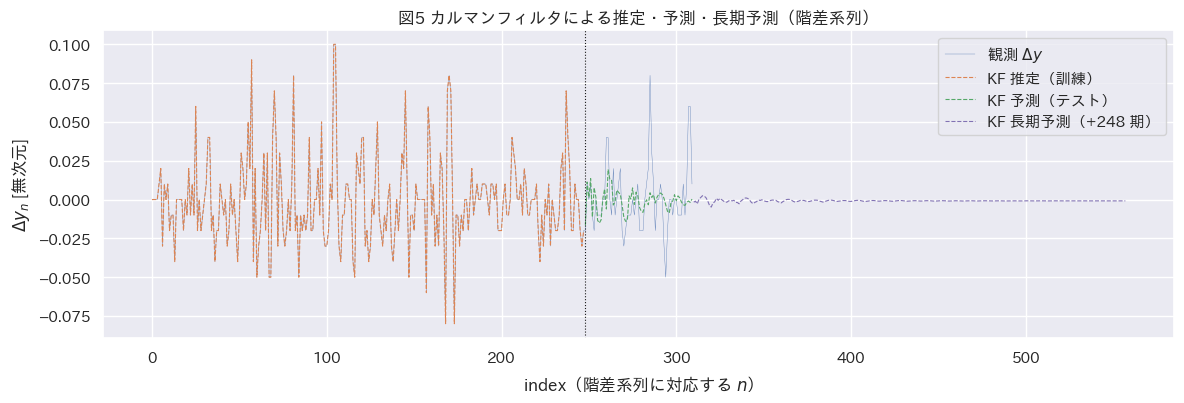

In [ ]:
from pykalman import KalmanFilter

popt = len(results.params) - 1  # 切片を除く AR 係数の個数（同伴形の次元）
n_dim_state = popt + 1
ar_const = float(results.params[0])
ar_coefs = np.asarray(results.params[1:], dtype=float).ravel()

f1 = ar_coefs.reshape(-1, 1)
f2 = np.eye(popt)
f2[-1, -1] = 0.0
f3 = np.zeros((1, n_dim_state))
f3[-1, -1] = 1.0
F = np.block([[f1, f2], [f3]])

G = np.zeros((n_dim_state, 1))
G[0, 0] = 1.0

H = np.zeros((1, n_dim_state))
H[0, 0] = 1.0
H[0, -1] = 1.0

Q = results.sigma2
R = 0.0

kf = KalmanFilter(
    n_dim_obs=1,
    n_dim_state=n_dim_state,
    initial_state_mean=ar_const * np.ones(n_dim_state),
    initial_state_covariance=np.eye(n_dim_state),
    transition_matrices=F,
    observation_matrices=H,
    observation_covariance=R,
    transition_covariance=G.dot(Q).dot(G.T),
)

filtered_state_means, filtered_state_covs = kf.filter(dy_train)
dy_kf_fit = filtered_state_means.dot(H.T)

current_state = filtered_state_means[-1]
current_cov = filtered_state_covs[-1]

dy_kf_fore = np.empty(len(dy_test))
for idx in range(len(dy_test)):
    current_state, current_cov = kf.filter_update(
        current_state, current_cov, observation=None
    )
    dy_kf_fore[idx] = current_state.dot(H.T)

N_LONG_EXTRA = min(5000, ntrain)
dy_long = np.empty(N_LONG_EXTRA)
for idx in range(N_LONG_EXTRA):
    current_state, current_cov = kf.filter_update(
        current_state, current_cov, observation=None
    )
    dy_long[idx] = current_state.dot(H.T)

fig, ax = plt.subplots(figsize=(12, 4.2))
ax.plot(np.arange(len(dy)), dy, lw=0.25, label="観測 $\\Delta y$")
ax.plot(np.arange(len(dy_kf_fit)), dy_kf_fit, "--", lw=0.8, label="KF 推定（訓練）")
ax.plot(np.arange(ntrain, ntrain + len(dy_kf_fore)), dy_kf_fore, "--", lw=0.8, label="KF 予測（テスト）")
long_t = np.arange(ntrain + len(dy_test), ntrain + len(dy_test) + N_LONG_EXTRA)
ax.plot(long_t, dy_long, "--", lw=0.8, color="C4", label=f"KF 長期予測（+{N_LONG_EXTRA} 期）")
ax.axvline(ntrain, color="k", ls=":", lw=0.8)
ax.set_xlabel("index（階差系列に対応する $n$）", labelpad=6)
ax.set_ylabel("$\\Delta y_n$ [無次元]")
ax.legend(loc="upper right")
fig.tight_layout()
fig.subplots_adjust(bottom=0.22)
fig.text(0.5, 0.02, "図5 カルマンフィルタによる推定・予測・長期予測（階差系列）", ha="center", va="bottom")
plt.show()

### （参考）階差予測を累積和で原系列に戻すプロット（教材と同様のイメージ）

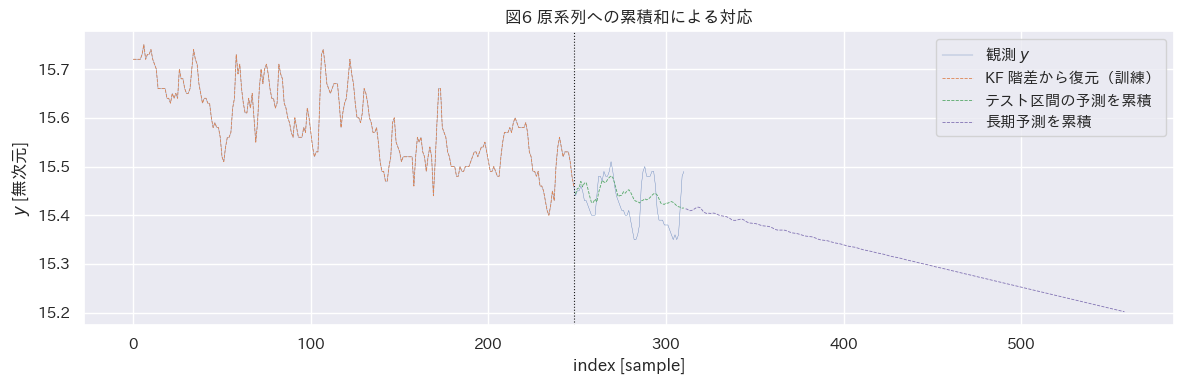

In [ ]:
y0 = float(y[0])
y_rec = np.concatenate([[y0], y0 + np.cumsum(dy_kf_fit)])  # 長さ ntrain+1 → y_0..y_{ntrain}
y_fore = y_rec[-1] + np.cumsum(dy_kf_fore)  # y_{ntrain+1}.. に対応
y_long_cum = y_fore[-1] + np.cumsum(dy_long)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(np.arange(len(y)), y, lw=0.25, label="観測 $y$")
ax.plot(np.arange(ntrain + 1), y_rec, "--", lw=0.6, label="KF 階差から復元（訓練）")
ax.plot(
    np.arange(ntrain + 1, ntrain + 1 + len(y_fore)),
    y_fore,
    "--",
    lw=0.6,
    label="テスト区間の予測を累積",
)
ax.plot(
    np.arange(ntrain + len(dy_test) + 1, ntrain + len(dy_test) + 1 + len(y_long_cum)),
    y_long_cum,
    "--",
    lw=0.6,
    color="C4",
    label="長期予測を累積",
)
ax.axvline(ntrain, color="k", ls=":", lw=0.8)
ax.set_xlabel("index [sample]")
ax.set_ylabel("$y$ [無次元]")
ax.legend(loc="upper right")
plt.tight_layout()
plt.subplots_adjust(bottom=0.22)
plt.gcf().text(0.5, 0.02, "図6 原系列への累積和による対応", ha="center", va="bottom")
plt.show()